In [16]:
from sklearn.datasets import fetch_lfw_people
from sklearn.metrics import confusion_matrix
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
# from imblearn.over_sampling import RandomOverSampler
     

### Data visualization

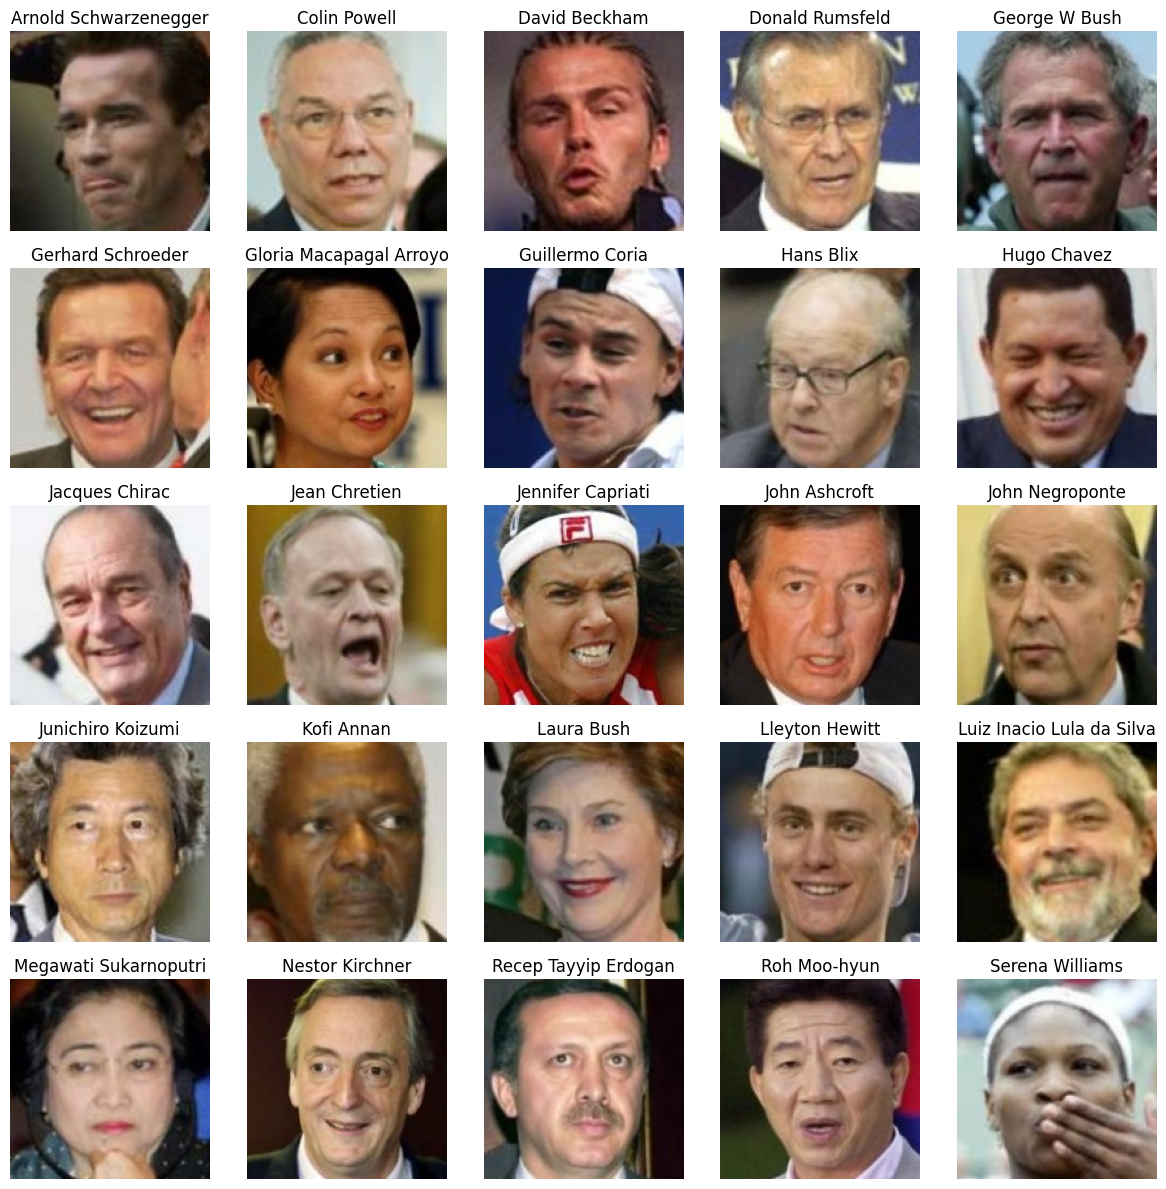

Dataset shape: (2370, 71148)
Total images: 2370
Image dimensions: 71148 pixels
Total labels: 2370
Reshaped image size: 154x154x3 pixels (RGB)
Number of people/classes: 34


In [46]:
# We use the following slicing to get more meaningful cut of images
lfw_people = fetch_lfw_people(min_faces_per_person=30, color=True, resize=1.0,
                              slice_=(slice(48, 202), slice(48, 202)))

# Get the data and target
X = lfw_people.data
labels = lfw_people.target
target_names = lfw_people.target_names
# print(target_names)

# Images are flattened, so we need to reshape them into 3 channels square images
total_pixels = X.shape[1] // 3  
height = int(total_pixels ** 0.5)  # Assuming square images
width = total_pixels // height

# Finding one image per person
fig, axes = plt.subplots(5, 5, figsize=(12, 12))
axes = axes.ravel() 
unique_labels = np.unique(labels)[4:29]
num_people = len(unique_labels)

for i, label in enumerate(unique_labels):
    # Find the first image for this person
    person_indices = np.where(labels == label)[0]
    first_image_idx = person_indices[0]
    
    # Reshape and display the image
    img = X[first_image_idx].reshape(height, width, 3)
    axes[i].imshow(img)
    axes[i].set_title(f'{target_names[label]}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print(f"Dataset shape: {X.shape}")
print(f"Total images: {X.shape[0]}")
print(f"Image dimensions: {X.shape[1]} pixels")
print(f"Total labels: {len(labels)}")
print(f"Reshaped image size: {height}x{width}x3 pixels (RGB)")
print(f"Number of people/classes: {len(target_names)}")
